# CNN: Training Keras (16 Arsitektur)

Notebook ini hanya mengerjakan bagian CNN untuk dataset Intel Image Classification. RNN dan LSTM tidak dipakai di sini.

## Setup

In [1]:
from pathlib import Path
import json
import random
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebook":
    PROJECT_ROOT = PROJECT_ROOT.parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.wajib.cnn.models import __run__
from src.wajib.cnn.utils import __loadbatch__, __loaddataset__

import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")
print("GPUs:", gpus)

for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATA_ROOT = PROJECT_ROOT / "data"
TRAIN_DIR = DATA_ROOT / "seg_train" / "seg_train"
TEST_DIR = DATA_ROOT / "seg_test" / "seg_test"
WEIGHTS_DIR = PROJECT_ROOT / "src" / "wajib" / "weights" / "cnn"
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

TARGET_SIZE = (64, 64)
BATCH_SIZE = 32
EPOCHS = 10
VALIDATION_SIZE = 0.2
MAX_PER_CLASS = None  # isi integer kecil, misalnya 250, kalau ingin smoke test cepat

I0000 00:00:1778415880.174380  704162 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1778415880.224226  704162 pjrt_api.cc:95] PJRT_Api is set for device type gpu
I0000 00:00:1778415880.234789  704162 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1778415883.013485  704162 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


GPUs: []


E0000 00:00:1778415883.691441  704162 cuda_executor.cc:1594] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1778415883.691990  721582 cuda_executor.cc:1614] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1778415883.714861  704162 gpu_device.cc:2364] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


## Load + Split Dataset

In [2]:
train_paths, train_labels, class_names = __loaddataset__(str(TRAIN_DIR))
test_paths, test_labels, _ = __loaddataset__(str(TEST_DIR), class_names=class_names)

def limit_per_class(paths, labels, max_per_class):
    if max_per_class is None:
        return paths, labels
    kept_paths, kept_labels = [], []
    per_class_count = {idx: 0 for idx in range(len(class_names))}
    for path, label in zip(paths, labels):
        if per_class_count[label] < max_per_class:
            kept_paths.append(path)
            kept_labels.append(label)
            per_class_count[label] += 1
    return kept_paths, kept_labels

train_paths, train_labels = limit_per_class(train_paths, train_labels, MAX_PER_CLASS)
test_paths, test_labels = limit_per_class(test_paths, test_labels, MAX_PER_CLASS)

train_paths, val_paths, y_train, y_val = train_test_split(
    train_paths,
    train_labels,
    test_size=VALIDATION_SIZE,
    random_state=SEED,
    stratify=train_labels,
)

print("Classes:", class_names)
print(f"Train: {len(train_paths)} | Val: {len(val_paths)} | Test: {len(test_paths)}")


Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']
Train: 11227 | Val: 2807 | Test: 3000


## Convert Gambar to Array

In [3]:
X_train = __loadbatch__(train_paths, target_size=TARGET_SIZE)
X_val = __loadbatch__(val_paths, target_size=TARGET_SIZE)
X_test = __loadbatch__(test_paths, target_size=TARGET_SIZE)

y_train = np.asarray(y_train, dtype=np.int64)
y_val = np.asarray(y_val, dtype=np.int64)
y_test = np.asarray(test_labels, dtype=np.int64)

input_shape = X_train.shape[1:]
num_classes = len(class_names)

print("Input shape:", input_shape)
print("Num classes:", num_classes)


Input shape: (64, 64, 3)
Num classes: 6


## Train 16 arsitektur CNN

In [4]:
# satu dulu
results = __run__(
    X_train,
    y_train,
    X_val,
    y_val,
    X_test,
    y_test,
    input_shape=input_shape,
    num_classes=num_classes,
    weights_dir=str(WEIGHTS_DIR),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
)

with open(WEIGHTS_DIR / "class_names.json", "w", encoding="utf-8") as f:
    json.dump(class_names, f, indent=2)


Epoch 1/10


W0000 00:00:1778415913.182621  704162 cpu_allocator_impl.cc:82] Allocation of 551829504 exceeds 10% of free system memory.


  2/351 ━━━━━━━━━━━━━━━━━━━━ 44s 127ms/step - accuracy: 0.1953 - loss: 1.7879

W0000 00:00:1778415916.261041  721899 cpu_allocator_impl.cc:82] Allocation of 24772608 exceeds 10% of free system memory.
W0000 00:00:1778415916.261405  721898 cpu_allocator_impl.cc:82] Allocation of 24772608 exceeds 10% of free system memory.
W0000 00:00:1778415916.348192  721899 cpu_allocator_impl.cc:82] Allocation of 24772608 exceeds 10% of free system memory.
W0000 00:00:1778415916.348192  721903 cpu_allocator_impl.cc:82] Allocation of 24772608 exceeds 10% of free system memory.


351/351 ━━━━━━━━━━━━━━━━━━━━ 35s 94ms/step - accuracy: 0.6436 - loss: 0.9413 - val_accuracy: 0.7357 - val_loss: 0.7534
Epoch 2/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 43s 123ms/step - accuracy: 0.7555 - loss: 0.6606 - val_accuracy: 0.7289 - val_loss: 0.7236
Epoch 3/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 59s 167ms/step - accuracy: 0.8106 - loss: 0.5189 - val_accuracy: 0.7634 - val_loss: 0.7089
Epoch 4/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 59s 167ms/step - accuracy: 0.8524 - loss: 0.3997 - val_accuracy: 0.7952 - val_loss: 0.6193
Epoch 5/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 59s 168ms/step - accuracy: 0.8969 - loss: 0.2901 - val_accuracy: 0.7802 - val_loss: 0.6754
Epoch 6/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 59s 167ms/step - accuracy: 0.9307 - loss: 0.1997 - val_accuracy: 0.7691 - val_loss: 0.8230
Epoch 7/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 59s 168ms/step - accuracy: 0.9513 - loss: 0.1448 - val_accuracy: 0.7927 - val_loss: 0.7957
Epoch 8/10
351/351 ━━━━━━━━━━━━━━━━━━━━ 53s 151ms/step - accuracy: 0.9644 - loss: 0.1066 - val_

## Hasil Eksperimen

In [5]:
rows = []
for item in results:
    rows.append({
        "name": item["name"],
        "num_conv_layers": item["config"]["num_conv_layers"],
        "num_filters": item["config"]["num_filters"],
        "filter_sizes": item["config"]["filter_sizes"],
        "pooling_type": item["config"]["pooling_type"],
        "accuracy": item["metrics"]["accuracy"],
        "macro_f1": item["metrics"]["macro_f1"],
        "params": item["params"],
        "weights_path": item["weights_path"],
    })

results_df = pd.DataFrame(rows).sort_values("macro_f1", ascending=False).reset_index(drop=True)
results_df.to_csv(WEIGHTS_DIR / "cnn_experiment_results.csv", index=False)
display(results_df)

best_result = results_df.iloc[0]
print("Best model:", best_result["name"])
print("Best weights:", best_result["weights_path"])


,name,num_conv_layers,num_filters,filter_sizes,pooling_type,accuracy,macro_f1,params,weights_path
0,cnn_conv_L2_F32-64_K3-3_Pmax,2,"[32, 64]","[3, 3]",max,0.787333,0.787658,2117446,/home/stahlynx/Coding/Semester-6/ML/Tejumama_I...


Best model: cnn_conv_L2_F32-64_K3-3_Pmax
Best weights: /home/stahlynx/Coding/Semester-6/ML/Tejumama_Image-Captioning/src/wajib/weights/cnn/cnn_conv_L2_F32-64_K3-3_Pmax.keras


## Analisis

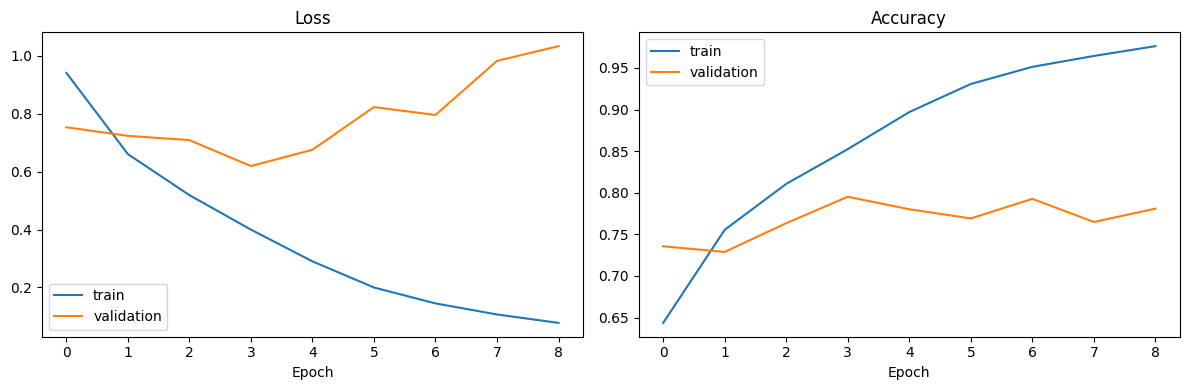

In [6]:
best_name = best_result["name"]
best_history = next(item["history"] for item in results if item["name"] == best_name)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(best_history["loss"], label="train")
axes[0].plot(best_history["val_loss"], label="validation")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].legend()

axes[1].plot(best_history["accuracy"], label="train")
axes[1].plot(best_history["val_accuracy"], label="validation")
axes[1].set_title("Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()
